# Week 5 — Classification Models (Part 1)

Week 4 measured what ignorance is worth: a `DummyClassifier` that never looks at
a feature scores **4.55%** (1/22) under 5-fold stratified cross-validation. That
is the floor.

**Part 1** (Week 5) puts the first three real algorithms on top of it:

* **Logistic regression** — a linear model; weighted sums of the features,
  turned into 22 probabilities by softmax.
* **k-nearest neighbours** — a distance-based model; look up the most similar
  training fields and take a vote.
* **Gaussian naive Bayes** — a probabilistic model; Bayes' rule plus one
  deliberately wrong independence assumption.

All three are trained through the same three-line loop, measured on the *same*
cross-validation folds, and collected in one results table. That table is
**extended** by later weeks, never replaced.

**Part 2** (Week 6, from §8 onwards) adds two more algorithms to the same table —
a support vector machine and a decision tree — and uses the tree to make
overfitting and the bias-variance tradeoff visible rather than verbal.

What this notebook does not do: tune a single hyperparameter or search for one
systematically, build an ensemble, explain which features matter (Week 7), or
open `data/processed/test.csv` (Week 8).


## 0. Setup

Same pattern as Weeks 1-4: repository root onto `sys.path`, then import the
logic from `src/` instead of writing it inline. This week's new module is
`src/models/classical_models.py` (`get_logistic_regression`, `get_knn`,
`get_naive_bayes`), covered by `tests/test_classical_models.py`.

Everything else is already built: the Week 3 preprocessor, the Week 4 evaluation
helpers, and `data/processed/train.csv`. The 440 test rows stay untouched.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

from src.data import DEFAULT_RANDOM_STATE, EXPECTED_LABEL_COUNT, FEATURE_COLUMNS, TARGET_COLUMN
from src.evaluation import DEFAULT_CV_FOLDS, cross_validated_accuracy, evaluate_model
from src.models import get_baseline_model, get_knn, get_logistic_regression, get_naive_bayes
from src.preprocessing import build_preprocessor

pd.set_option("display.width", 120)

print("seed", DEFAULT_RANDOM_STATE, "| folds", DEFAULT_CV_FOLDS, "| classes", EXPECTED_LABEL_COUNT)

seed 42 | folds 5 | classes 22


In [2]:
FEATURES = list(FEATURE_COLUMNS)

train = pd.read_csv(REPO_ROOT / "data" / "processed" / "train.csv")
X_train = train[FEATURES]
y_train = train[TARGET_COLUMN]

assert X_train.shape == (1_760, 7)
assert y_train.nunique() == EXPECTED_LABEL_COUNT

print("training rows:", len(train), "| features:", len(FEATURES))

training rows: 1760 | features: 7


## 1. The training loop, named once

Every model from here to Week 12 is trained with the same two calls. Learn the
shape now and nothing later is new:

```python
model.fit(X_train, y_train)      # learn from labelled rows
model.predict(X_test)            # answer for rows it has never seen
```

That is the whole scikit-learn estimator API for supervised learning:
`fit(X, y)` learns and stores parameters on the object, `predict(X)` applies
them. A random forest, a gradient booster and a tuned pipeline are all driven
by exactly these two methods — which is what makes swapping algorithms a
one-word change rather than a rewrite.

Two rules travel with it:

* `fit` sees **training rows only**. Anything it learns from a row the model is
  later scored on is data leakage (Weeks 2-3).
* The factories in `src/models/` return **unfitted** objects, so the caller
  decides what they are fitted on — and cross-validation can fit a fresh clone
  inside every fold.

Here it is, once, in full.


In [3]:
demo_model = get_naive_bayes()
demo_model.fit(X_train, y_train)                 # 1. learn
demo_predictions = demo_model.predict(X_train)   # 2. answer

print("model :", demo_model)
print("first five predictions:", [str(label) for label in demo_predictions[:5]])
print("first five true labels:", list(y_train[:5]))
print("training accuracy     :", round(evaluate_model(demo_model, X_train, y_train)["accuracy"], 4))

model : GaussianNB()
first five predictions: ['orange', 'grapes', 'kidneybeans', 'mothbeans', 'orange']
first five true labels: ['orange', 'grapes', 'kidneybeans', 'mothbeans', 'orange']
training accuracy     : 0.9949


That accuracy is measured on the rows the model just learned from, so it is not
evidence of anything — a model can memorise. Every number quoted from §5 onward
comes from cross-validation, where each score is computed on rows the model in
question did not see.

### The models travel inside the Week 3 pipeline

Two of this week's three algorithms care about the *units* of the features, so
they get the Week 3 `ColumnTransformer` in front of them:

```python
Pipeline([("preprocess", build_preprocessor()), ("model", model)])
```

A `Pipeline` is itself an estimator: `fit` fits the scaler and then the model,
`predict` transforms and then predicts. That matters for cross-validation — the
scaler is re-fitted inside every fold, on that fold's training rows only, so no
validation row's mean or standard deviation ever reaches the model that scores
it. Scaling the whole training set once, before splitting, would leak.


In [4]:
def make_pipeline(model) -> Pipeline:
    """Week 3's preprocessor followed by a Week 5 model, as one estimator."""
    return Pipeline([("preprocess", build_preprocessor()), ("model", model)])


pipeline = make_pipeline(get_logistic_regression())
pipeline.fit(X_train, y_train)
print(pipeline.named_steps)
print("prediction for the first field:", pipeline.predict(X_train.head(1))[0])

{'preprocess': ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['N', 'P', 'K', 'temperature', 'humidity',
                                  'ph', 'rainfall'])],
                  verbose_feature_names_out=False), 'model': LogisticRegression(max_iter=1000, random_state=42)}
prediction for the first field: orange


/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 2. Logistic regression — a linear decision boundary

Despite the name, logistic regression is a **classifier**. For each of the 22
crops it computes a weighted sum of the seven features,

```
score(crop) = w1*N + w2*P + w3*K + w4*temperature + w5*humidity + w6*ph + w7*rainfall + b
```

and converts the 22 scores into probabilities with the **softmax** function
(exponentiate, then divide by the total), so they are positive and sum to 1. The
predicted crop is the one with the highest probability. Training chooses the
weights that make the observed training labels as probable as possible.

Because every score is linear in the features, the surface separating any two
crops is **flat**: a line in two dimensions, a plane in three, a hyperplane in
seven. Logistic regression can only draw straight cuts through feature space. If
the true boundary curves, no amount of data will fix that — a different model
family will.

**Softmax vs. one-vs-rest.** Two ways to make a two-class method handle 22
classes: fit a single model over all classes at once (multinomial / softmax), or
fit 22 separate "is it rice or not?" models and take the most confident answer
(one-vs-rest, OvR). scikit-learn 1.6 uses softmax here because the default
`lbfgs` solver supports it; OvR is available via `OneVsRestClassifier` and is
what you fall back to for methods that cannot do better.

`C` is the **inverse** regularisation strength: small `C` pulls the weights
towards zero (a simpler, flatter model), large `C` lets them grow to fit the
training data more closely. It is left at 1.0 this week — choosing it by trying
values and keeping the best is what a hyperparameter search does, in a later
week.

The cell below also calls a third method: `predict_proba(X)`. Where
`predict` returns one label per row, `predict_proba` returns the 22
probabilities behind that label — one per class, in `classes_` order, each row
summing to 1. Every classifier this week provides it, and `predict` is simply
the class with the largest of those numbers.


In [5]:
logistic = make_pipeline(get_logistic_regression()).fit(X_train, y_train)
coefficients = logistic.named_steps["model"].coef_

print("coefficient matrix:", coefficients.shape, "= (22 crops, 7 features)")
print("intercepts        :", logistic.named_steps["model"].intercept_.shape)
print("learned numbers   :", coefficients.size + logistic.named_steps["model"].intercept_.size)

probabilities = logistic.predict_proba(X_train.head(1))[0]
top = np.argsort(probabilities)[::-1][:3]
print("\nmost probable crops for the first field:")
for index in top:
    print(f"  {logistic.classes_[index]:<12} {probabilities[index]:.3f}")
print("probabilities sum to", round(probabilities.sum(), 6))

coefficient matrix: (22, 7) = (22 crops, 7 features)
intercepts        : (22,)
learned numbers   : 176

most probable crops for the first field:
  orange       0.852
  coconut      0.044
  mungbean     0.044
probabilities sum to 1.0


/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


176 numbers is the entire model: 22 x 7 weights and 22 intercepts. Nothing else
is stored — the training rows themselves are discarded once fitting is done.
Compare that with the next algorithm, which stores all 1,760 of them.

Reading the weights (which crop is pushed up by rainfall, which by potassium) is
Week 7's subject; note only that they *can* be read. That is a real advantage of
linear models and a reason to keep one in the comparison even if it does not
win.


## 3. k-nearest neighbours — prediction by similarity

KNN barely trains at all. `fit` stores the training rows; that is its entire
learning. `predict` does the work: for a new field, measure the distance to
every stored field, keep the `k` closest, and return the most common label among
them. It is the standard example of a **lazy learner** — cost deferred from
training to prediction.

There is no equation of a boundary here. The boundary is implied by the data,
and it can be any shape at all — which is why KNN handles curved class regions
that logistic regression cannot, and why it can never tell you *why* it answered
as it did beyond "the neighbours said so".

### The effect of k

`k` is a smoothness dial:

* `k = 1` — the boundary follows every training point exactly. Training accuracy
  is a perfect and utterly uninformative 100%, and one mislabelled row owns its
  whole neighbourhood. This is the overfitting end.
* moderate `k` — votes average over a small region, so single odd rows are
  outvoted.
* very large `k` — the neighbourhood grows until it covers most of the data and
  the model converges on "predict the most common class", i.e. the Week 4
  baseline. This is the underfitting end.

The sweep below is a *demonstration* of that curve, not a hyperparameter search:
the value is not adopted, and picking `k` properly — with a search, on a stated
protocol — comes later in the course.


In [6]:
k_values = [1, 3, 5, 11, 25, 51, 101, 201, 401]
k_sweep = pd.DataFrame(
    [
        {
            "k": k,
            "cv accuracy": round(
                cross_validated_accuracy(make_pipeline(get_knn(n_neighbors=k)), X_train, y_train)[
                    "mean"
                ],
                4,
            ),
        }
        for k in k_values
    ]
).set_index("k")

k_sweep

,cv accuracy
k,
1,0.9665
3,0.9642
5,0.9653
11,0.9534
25,0.9267
51,0.8705
101,0.7710
201,0.6602
401,0.5409


Accuracy is flat for small `k`, then falls away as the neighbourhood swells: at
`k = 401` each vote is drawn from nearly a quarter of the training set, and
crops that occupy small regions of feature space are simply outvoted. Continue
far enough and the curve would arrive at 4.55%.

### Scaling, and why KNN is the model that cares most

KNN's answer is entirely determined by distances, and distances mix all seven
columns into one number. `K` spans about 200 units, `ph` about 6 — so on raw
data a one-unit change in `ph` is invisible next to potassium, whatever it means
agronomically. Standardising first (Week 3) puts every feature on the same
footing, which is the *principled* default and the reason the preprocessor is in
front of every model here.

Principled is not the same as always-better on one dataset:


In [7]:
scaled = cross_validated_accuracy(make_pipeline(get_knn()), X_train, y_train)["mean"]
unscaled = cross_validated_accuracy(get_knn(), X_train, y_train)["mean"]

print("KNN, standardised features:", round(scaled, 4))
print("KNN, raw features         :", round(unscaled, 4))

KNN, standardised features: 0.9653
KNN, raw features         : 0.9767


The raw-feature version scores slightly *higher* here. That is not evidence
against scaling; it is evidence that on this dataset the raw units happen to
weight the most discriminative features (rainfall, humidity, `K`) more heavily,
by accident. The gap is about a percentage point and within a couple of standard
deviations of the fold spread — a difference this small is not yet a difference
(Week 4 §6). Keeping the scaler keeps the comparison between algorithms rather
than between accidental weightings, and it is the choice that generalises to the
next dataset.

### The curse of dimensionality, briefly

Distance-based reasoning degrades as columns are added. In high dimensions the
distances between points concentrate: the nearest neighbour ends up almost as
far away as the farthest, so "nearest" stops implying "similar", and every extra
uninformative column dilutes the informative ones. It is why KNN struggles on
data with hundreds or thousands of features unless something reduces them first.

Seven features is comfortably safe. The effect is easy to *stage*, though —
append 100 columns of pure noise to the seven real ones and watch the same model
collapse:


In [8]:
rng = np.random.default_rng(seed=DEFAULT_RANDOM_STATE)
noise = pd.DataFrame(
    rng.normal(0.0, 1.0, (len(X_train), 100)),
    columns=[f"noise_{i}" for i in range(100)],
)
X_noisy = pd.concat([X_train.reset_index(drop=True), noise], axis=1)
noisy_pipeline = Pipeline(
    [("preprocess", build_preprocessor(list(X_noisy.columns))), ("model", get_knn())]
)

clean_knn = cross_validated_accuracy(make_pipeline(get_knn()), X_train, y_train)["mean"]
noisy_knn = cross_validated_accuracy(noisy_pipeline, X_noisy, y_train)["mean"]

print("7 real features   :", round(clean_knn, 4))
print("7 real + 100 noise:", round(noisy_knn, 4))

7 real features   : 0.9653
7 real + 100 noise: 0.2233


The information did not go anywhere — the seven real columns are still there —
but it has been buried in a distance that is now mostly noise. Logistic
regression and naive Bayes are hurt far less by the same columns, because they
weight (or model) each feature separately rather than summing them all into one
distance.

## 4. Gaussian naive Bayes — probability with a wrong assumption

Bayes' rule turns the question round. What we want is `P(crop | field)`; what is
easy to estimate from training data is `P(field | crop)`:

```
P(crop | field)  ∝  P(field | crop) * P(crop)
```

The `∝` means "proportional to": the missing denominator `P(field)` is the
same for all 22 crops, so it cannot change which of them is largest and is
dropped. `P(crop)` is just the class frequency (1/22 here — the classes are
balanced).
`P(field | crop)` is a seven-dimensional joint distribution, which is hard. So
naive Bayes assumes the features are **independent given the class**, letting
that joint probability factorise into a product of seven one-dimensional ones,
and **Gaussian** naive Bayes models each of those as a normal curve.

Fitting therefore reduces to computing a mean and a variance per feature per
class: 22 x 7 x 2 = 308 numbers, in a single pass over the data. There is no
iterative optimisation and no distance computation, which is why it is the
fastest of the three by a wide margin.


In [9]:
naive_bayes = make_pipeline(get_naive_bayes()).fit(X_train, y_train)
nb_model = naive_bayes.named_steps["model"]

print("class means    :", nb_model.theta_.shape, "= (22 crops, 7 features)")
print("class variances:", nb_model.var_.shape)
print("class priors   :", np.round(nb_model.class_prior_[:3], 4), "... all equal, as expected")

# The assumption is false on this data: Week 2 measured strong correlations.
correlations = X_train.corr().abs()
np.fill_diagonal(correlations.values, 0.0)
strongest = correlations.stack().idxmax()
print(f"\nstrongest feature correlation: {strongest[0]}/{strongest[1]} =",
      round(correlations.loc[strongest], 3))

class means    : (22, 7) = (22 crops, 7 features)
class variances: (22, 7)
class priors   : [0.0455 0.0455 0.0455] ... all equal, as expected

strongest feature correlation: P/K = 0.736


`P` and `K` correlate at 0.74, so "independent given the class" is simply not
true here — and the model works anyway. Two reasons this is less paradoxical
than it sounds:

* **Classification needs a ranking, not a calibration.** Only the *largest* of
  the 22 class scores decides the answer. Correlated features effectively get
  counted twice, which makes the winning probability wildly overconfident (often
  0.999-something), but usually leaves the winner unchanged.
* **Few parameters, little variance.** 308 numbers estimated from 1,760 rows are
  all estimated well. A model with a more faithful assumption and far more
  parameters can easily do worse on data this size.

So: trust naive Bayes' predictions more than its probabilities. And treat it as
the "second baseline" — a fast, assumption-driven model that a well-chosen
algorithm ought to beat. On this dataset, as §5 shows, that turns out to be a
demanding bar.

Unlike the other two, this model is *unaffected* by standardisation — rescaling
a column moves every class's mean and variance for that column identically. The
preprocessor stays in front of it only so that all three models receive exactly
the same inputs.


## 5. Comparing the three fairly

"Fairly" has a precise meaning: **the same data, the same folds, the same
metric, the same protocol** for every candidate. `cross_validated_accuracy` uses
`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`, so all four rows
of the table below are scored on the identical five partitions of the same 1,760
rows. Comparing a model cross-validated on one seed against another on a
different seed measures the seeds as much as the models.

Two further habits the table encodes:

* **Report the spread, not just the mean.** A gap between two models smaller
  than their fold-to-fold standard deviation is not yet a gap.
* **Keep the baseline in the table.** Every accuracy is meaningless without the
  4.55% floor beside it.


In [10]:
candidates = {
    "baseline (most_frequent)": get_baseline_model(),
    "logistic regression": get_logistic_regression(),
    "knn (k=5)": get_knn(),
    "naive bayes": get_naive_bayes(),
}

rows = []
for name, model in candidates.items():
    outcome = cross_validated_accuracy(make_pipeline(model), X_train, y_train)
    rows.append(
        {
            "model": name,
            **{f"fold {i}": round(score, 4) for i, score in enumerate(outcome["scores"], start=1)},
            "mean": round(outcome["mean"], 4),
            "std": round(outcome["std"], 4),
        }
    )

results = pd.DataFrame(rows).set_index("model")
results

/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,fold 1,fold 2,fold 3,fold 4,fold 5,mean,std
model,,,,,,,
baseline (most_frequent),0.0455,0.0455,0.0455,0.0455,0.0455,0.0455,0.0000
logistic regression,0.9659,0.9574,0.9688,0.9716,0.9773,0.9682,0.0066
knn (k=5),0.9830,0.9716,0.9460,0.9631,0.9631,0.9653,0.0121
naive bayes,1.0000,0.9972,0.9886,0.9915,0.9972,0.9949,0.0042


The table above is the raw record: five fold scores per model, plus their mean
and standard deviation. The next cell derives the two columns that make it
readable — how far each model sits above the 4.55% floor, and its error rate
(`1 - accuracy`), which is the sharper way to compare models that are all close
to 100%.


In [11]:
baseline_accuracy = results.loc["baseline (most_frequent)", "mean"]
summary = results[["mean", "std"]].copy()
summary["vs baseline"] = (summary["mean"] - baseline_accuracy).round(4)
summary["error rate"] = (1 - summary["mean"]).round(4)

print(summary.to_string())
print("\nbest this week:", summary.drop(index="baseline (most_frequent)")["mean"].idxmax())

                            mean     std  vs baseline  error rate
model                                                            
baseline (most_frequent)  0.0455  0.0000       0.0000      0.9545
logistic regression       0.9682  0.0066       0.9227      0.0318
knn (k=5)                 0.9653  0.0121       0.9198      0.0347
naive bayes               0.9949  0.0042       0.9494      0.0051

best this week: naive bayes


### Reading the table

* **All three beat the baseline by more than 90 percentage points.** That is the
  first thing to check and the only thing that was ever in doubt: the seven
  features carry real information about which crop suits a field, and each
  algorithm extracted it.
* **Naive Bayes wins, at ~99.5%.** The simplest, fastest, most obviously
  misspecified model of the three is the most accurate. Week 2 explains why: the
  crops occupy compact, well-separated blobs in feature space, and "one Gaussian
  per crop per feature" is an almost perfect description of exactly that shape.
  The lesson is not "naive Bayes is best" but "model complexity is not a
  ranking; fit between the model's assumptions and the data's shape is".
* **Logistic regression (~96.8%) and KNN (~96.5%) are not separated by this
  experiment.** Their means differ by ~0.3 points while KNN's fold standard
  deviation alone is ~1.2 points. Declaring a winner there would be reading
  noise; distinguishing them properly needs repeated cross-validation or a
  statistical test, which comes later in the course.
* **Look at error rates, not just accuracies.** Naive Bayes' 0.5% error against
  logistic regression's 3.2% is a six-fold difference in mistakes, which the
  accuracy column understates.

### When would you prefer KNN over logistic regression?

* When the class regions are **curved or fragmented** — KNN follows any shape,
  logistic regression only cuts straight.
* When the feature count is **small** and rows are plentiful, so distances stay
  meaningful and the lookup stays cheap.
* When training must be **instant** and new labelled rows arrive constantly:
  adding data to KNN is appending to a list, with no refit.

Prefer logistic regression when you need the model to be **explainable** (Week
7), when prediction must be fast or the model small (176 numbers versus 1,760
stored rows), when there are **many features**, or when calibrated probabilities
matter.


## 6. The result, and what it licenses

> ### Week 5 result — 5-fold stratified CV on the 1,760 training rows
>
> | Model | CV accuracy | vs. 4.55% baseline |
> | --- | --- | --- |
> | Gaussian naive Bayes | **99.49%** (±0.42) | +94.9 points |
> | Logistic regression | 96.82% (±0.66) | +92.3 points |
> | KNN, k = 5 | 96.53% (±1.21) | +92.0 points |
> | `most_frequent` baseline | 4.55% (±0.00) | — |

The current best is **Gaussian naive Bayes at 99.49%**, and every model here
clears the Week 4 floor by a margin far larger than any fold-to-fold wobble, so
"they beat the baseline" is a safe claim in a way that "naive Bayes beats
logistic regression by 2.7 points" is only *probably* safe and "logistic
regression beats KNN by 0.3 points" is not safe at all.

Three cautions to carry into Part 2:

* **These are untuned defaults.** `C = 1.0` and `k = 5` were chosen by
  scikit-learn, not by evidence. A later week searches properly, and the ranking
  may change.
* **No test-set number has been quoted.** `data/processed/test.csv` is still
  unopened; these are cross-validated *training* scores, used for choosing
  between models, and the final honest number comes in Week 8.
* **A 99.5% ceiling is a property of this dataset, not a sign of skill.** Week 2
  showed the crops are nearly separable. The later weeks are worth doing anyway,
  because how you tune, compare and evaluate is what transfers to data that is
  not this obliging.


In [12]:
best_model = summary.drop(index="baseline (most_frequent)")["mean"].idxmax()
best_accuracy = summary.loc[best_model, "mean"]

print(f"BEST SO FAR : {best_model} at {best_accuracy:.4f} ({best_accuracy:.2%})")
print(f"BASELINE    : {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")
print(f"protocol    : {DEFAULT_CV_FOLDS}-fold stratified CV, seed {DEFAULT_RANDOM_STATE},"
      " on data/processed/train.csv")

# Guard rails: these must hold for the conclusions above to be true.
assert baseline_accuracy < 0.06                       # Week 4's floor, unchanged
assert summary.drop(index="baseline (most_frequent)")["mean"].min() > 0.90
assert best_model == "naive bayes"
assert len(train) == 1_760                            # the test set was never touched

BEST SO FAR : naive bayes at 0.9949 (99.49%)
BASELINE    : 0.0455 (4.55%)
protocol    : 5-fold stratified CV, seed 42, on data/processed/train.csv


## 7. What this week produced, and what it deliberately did not

**Produced**

* `get_logistic_regression()`, `get_knn()` and `get_naive_bayes()` in
  `src/models/classical_models.py`, all returning unfitted estimators.
* The `fit(X_train, y_train)` / `predict(X_test)` loop, named once and reused by
  every model from here on.
* A four-row results table — three real models against the Week 4 baseline, on
  identical folds — **extended** by Part 2 below and by later weeks.
* The current leader: Gaussian naive Bayes, 99.49%.

**Not produced, on purpose**

* No tuned hyperparameter. `C = 1.0`, `k = 5` and `var_smoothing = 1e-9` are
  defaults; systematic searching comes later.
* No ensemble — no random forest, no gradient boosting, no voting classifier.
* No statement about which features drive a prediction — **Week 7**.
* No precision, recall, F1 or confusion matrix — **Week 8**.
* No test-set score. `data/processed/test.csv` remains unopened.


---

# Week 6 — Classification Models (Part 2)

Part 1 left a four-row table with Gaussian naive Bayes on top at **99.49%**. It
also left two gaps. Every model so far either draws a *flat* boundary (logistic
regression), draws *no* boundary at all and defers to the neighbours (KNN), or
describes each class with a *bell curve* (naive Bayes). And nothing so far has
been complex enough to overfit visibly — the word has been used, but not shown.

Part 2 closes both gaps with two more algorithms, added to the *same* table, on
the *same* folds:

* **Support vector machine** — a margin-based model. Of all the boundaries that
  separate two classes, it picks the one with the widest empty corridor around
  it, and a **kernel** lets that boundary curve.
* **Decision tree** — a rule-based model. A chain of `feature <= threshold`
  questions, chosen greedily; `max_depth` decides how many questions it may ask
  and therefore how badly it can overfit.

Then two pictures that the earlier weeks could only describe in words:

* **training accuracy against validation accuracy over tree depth** — the
  bias-variance tradeoff, drawn from this dataset;
* **a decision boundary on two features** — what the phrase actually looks like.

Nothing here is tuned. `C = 1.0` for the SVM and an unlimited tree are defaults,
the depth sweep is a demonstration and not a search, and
`data/processed/test.csv` stays closed.

## 8. Setup for Part 2

Two new factories from the same module (`get_svm`, `get_decision_tree`), one new
helper from `src/utils/visualization.py` (`plot_decision_boundary`), and
matplotlib. Everything else — `X_train`, `y_train`, `make_pipeline`, `results` —
is still in memory from Part 1, which is why this is one notebook rather than
two.

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import export_text

from src.models import get_decision_tree, get_svm
from src.utils.visualization import plot_decision_boundary

print("Part 1 results table still in memory:", list(results.index))

Part 1 results table still in memory: ['baseline (most_frequent)', 'logistic regression', 'knn (k=5)', 'naive bayes']


## 9. Support vector machines — the widest gap

Suppose two classes can be separated by a straight line. Then they can usually
be separated by infinitely many straight lines, and logistic regression's choice
among them comes from its loss function rather than from any geometric argument.
An SVM makes the choice explicit: **put the boundary where the gap to the nearest
training row of either class is as wide as possible.** That gap is the *margin*,
and the rows touching its edges are the *support vectors*.

Two consequences follow, and both matter on a dataset this size:

* **Only the support vectors decide the boundary.** Every other row could be
  deleted and the fitted model would be identical. The model is defined by the
  hardest cases, not by the bulk of easy ones.
* **A wide margin is a form of caution.** A boundary jammed against the training
  points is easily moved by one new point; a boundary in the middle of a wide
  corridor is not. This is why SVMs tend to do well on small tabular datasets —
  they spend their capacity on the few rows that are genuinely ambiguous.

Real data is rarely perfectly separable, so scikit-learn maximises a **soft**
margin: rows may sit inside the corridor, or on the wrong side of it, at a price
set by `C`. Small `C` = cheap violations = wider, smoother margin = more bias.
Large `C` = expensive violations = the boundary bends to accommodate individual
rows = more variance. It is the same `C` as in logistic regression, playing the
same role.

In [14]:
svm_pipeline = make_pipeline(get_svm()).fit(X_train, y_train)
fitted_svm = svm_pipeline.named_steps["model"]

print("kernel                :", fitted_svm.kernel)
print("training rows         :", len(X_train))
print("support vectors       :", int(fitted_svm.n_support_.sum()))
print("share of training rows:", round(fitted_svm.n_support_.sum() / len(X_train), 3))
print("support vectors per crop (first five):", fitted_svm.n_support_[:5])

kernel                : rbf
training rows         : 1760
support vectors       : 943
share of training rows: 0.536
support vectors per crop (first five): [22 35 56 20 37]


943 of 1,760 rows — 54% — are support vectors. That is high because there are 22
classes, so there are many pairs of crops with a boundary between them and each
boundary needs its own supporting rows; with two well-separated classes the share
would be a few per cent.

### What the kernel does

A **kernel** is a similarity function between two rows, and it is exactly the
inner product those rows *would have* in some higher-dimensional space. The SVM
only ever needs inner products, so it can fit a flat boundary in that space
without computing a single coordinate there — the **kernel trick** — and a flat
boundary up there folds back into a curved boundary down here.

In one sentence: **a kernel lets an SVM draw a curved boundary by measuring
similarity instead of position.**

* `linear` — plain inner product; the boundary stays flat, like logistic
  regression's, but positioned by the margin rather than by likelihood.
* `rbf` (radial basis function) — similarity that decays with distance, so each
  training row influences a bubble around itself. The boundary can enclose
  regions. `gamma` sets how quickly the influence dies off: large `gamma` = small
  bubbles = a wiggly boundary that can encircle single points (overfitting),
  small `gamma` = large bubbles = a boundary that flattens out (underfitting).

The sweep below varies `C` at the default `rbf` kernel and reports both the
cross-validated accuracy and the number of support vectors, which is the visible
trace of the margin narrowing.

In [15]:
svm_rows = []
for c_value in [0.01, 0.1, 1.0, 10.0, 100.0]:
    fitted = make_pipeline(get_svm(C=c_value)).fit(X_train, y_train).named_steps["model"]
    svm_rows.append(
        {
            "C": c_value,
            "support vectors": int(fitted.n_support_.sum()),
            "cv accuracy": round(
                cross_validated_accuracy(make_pipeline(get_svm(C=c_value)), X_train, y_train)[
                    "mean"
                ],
                4,
            ),
        }
    )

svm_sweep = pd.DataFrame(svm_rows).set_index("C")
svm_sweep

,support vectors,cv accuracy
C,,
0.01,1760,0.8716
0.10,1608,0.9352
1.00,943,0.9790
10.00,640,0.9824
100.00,612,0.9818


At `C = 0.01` violations are so cheap that the margin swallows the entire
training set — all 1,760 rows are support vectors — and accuracy falls to 87.2%:
underfitting. As `C` grows the margin tightens, the support-vector count drops
towards 600, and accuracy settles around 98%. Note that none of these numbers is
adopted: `C = 1.0` stays, and choosing it from this table would be picking a
hyperparameter by looking at validation scores, which is what a proper search
does under a stated protocol.

### Linear versus RBF on this dataset

In [16]:
for kernel_name in ["linear", "rbf"]:
    outcome = cross_validated_accuracy(
        make_pipeline(get_svm(kernel=kernel_name)), X_train, y_train
    )
    print(f"{kernel_name:>6} kernel: {outcome['mean']:.4f} (+/- {outcome['std']:.4f})")

linear kernel: 0.9818 (+/- 0.0077)


   rbf kernel: 0.9790 (+/- 0.0103)


The linear kernel is *not* beaten by the RBF one here (98.18% against 97.90%,
inside the fold spread of either). That is informative rather than
disappointing: Week 2 showed the 22 crops occupy compact, well-separated regions,
and separating compact blobs is a job a flat boundary already does. A curved
boundary is worth paying for when the classes are interleaved or one encloses
another — and this dataset simply is not like that. "Use the more flexible model"
is not a rule; matching the model to the shape of the data is.

## 10. Decision trees — a chain of questions

A decision tree asks one kind of question, `feature <= threshold`, and does so
greedily: at each node it tries every feature and every candidate threshold,
scores the resulting two groups by how **pure** they are, keeps the best split,
and repeats inside each group.

Purity is measured by the `criterion`:

* **Gini impurity** — the probability of mislabelling a randomly chosen row in
  the node if you guessed labels at the node's own class frequencies. Zero for a
  node holding a single class, largest when its classes are evenly mixed.
* **Entropy** — the number of bits needed to encode the node's labels. Same zero,
  same maximum, a different curve between them.

The split chosen is the one that reduces the weighted average impurity of the
children the most — the *information gain*. Nothing here is deep mathematics, and
the two criteria almost always choose the same splits; Gini is the default
because it avoids a logarithm.

The first two questions this tree asks on the crop data are printed below.

In [17]:
print(export_text(get_decision_tree(max_depth=2).fit(X_train, y_train), feature_names=FEATURES))

full_tree_pipeline = make_pipeline(get_decision_tree()).fit(X_train, y_train)
full_tree = full_tree_pipeline.named_steps["model"]
print("unlimited tree — depth:", full_tree.get_depth(), "| leaves:", full_tree.get_n_leaves())
print("training accuracy     :", evaluate_model(full_tree_pipeline, X_train, y_train)["accuracy"])

|--- rainfall <= 30.18
|   |--- class: muskmelon
|--- rainfall >  30.18
|   |--- humidity <= 27.98
|   |   |--- class: chickpea
|   |--- humidity >  27.98
|   |   |--- class: apple

unlimited tree — depth: 17 | leaves: 38
training accuracy     : 1.0


Two things to notice.

* **The rules are readable.** "Is rainfall under 30 mm? Then muskmelon." That is
  a sentence a farmer could check, and no other model in this project produces
  one. It is why Week 7 returns to trees for explainability.
* **The unlimited tree scores 100% on its training data.** It kept splitting
  until every leaf was pure. That number is not a result; it is the definition of
  the algorithm's stopping rule, and the clearest example of overfitting
  available.

Trees are also the one model here that is **indifferent to feature scaling** — a
split at `rainfall <= 30.18` selects the same rows however the column is centred
or divided. The Week 3 preprocessor stays in front of it only so that every model
in the comparison receives identical inputs.

## 11. Depth, overfitting, and the bias-variance tradeoff

Now the picture the whole week is built around. For a range of `max_depth`
values, fit the tree on all 1,760 training rows and record two numbers:

* **training accuracy** — measured on the rows it was fitted on;
* **validation accuracy** — the mean of the five stratified cross-validation
  folds, each scored on rows that fold's model never saw.

The test set is not involved. "Test" in the phrase *train-vs-test curve* means
"data held out from fitting", and cross-validation supplies that while keeping
`data/processed/test.csv` closed until Week 8.

In [18]:
depth_rows = []
for depth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, None]:
    fitted = make_pipeline(get_decision_tree(max_depth=depth)).fit(X_train, y_train)
    validated = cross_validated_accuracy(
        make_pipeline(get_decision_tree(max_depth=depth)), X_train, y_train
    )
    depth_rows.append(
        {
            "max_depth": fitted.named_steps["model"].get_depth() if depth is None else depth,
            "leaves": int(fitted.named_steps["model"].get_n_leaves()),
            "train accuracy": round(evaluate_model(fitted, X_train, y_train)["accuracy"], 4),
            "validation accuracy": round(validated["mean"], 4),
        }
    )

depth_sweep = pd.DataFrame(depth_rows).set_index("max_depth")
depth_sweep["gap"] = (depth_sweep["train accuracy"] - depth_sweep["validation accuracy"]).round(4)
depth_sweep

,leaves,train accuracy,validation accuracy,gap
max_depth,,,,
1,2,0.0909,0.0909,0.0000
2,3,0.1364,0.1364,0.0000
3,5,0.2273,0.2261,0.0012
4,7,0.3182,0.3170,0.0012
5,9,0.4091,0.4074,0.0017
6,13,0.5830,0.5636,0.0194
7,17,0.7608,0.7381,0.0227
8,21,0.8949,0.8716,0.0233
9,25,0.9443,0.9477,-0.0034


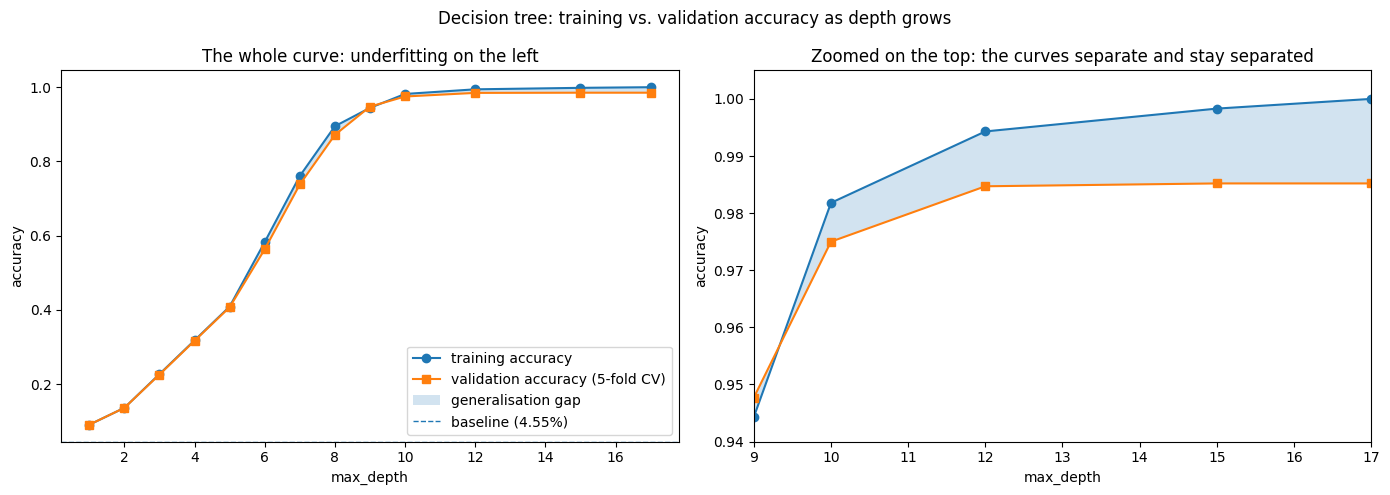

In [19]:
figure, (whole, zoom) = plt.subplots(1, 2, figsize=(14, 5))

for panel in (whole, zoom):
    panel.plot(
        depth_sweep.index, depth_sweep["train accuracy"], marker="o", label="training accuracy"
    )
    panel.plot(
        depth_sweep.index,
        depth_sweep["validation accuracy"],
        marker="s",
        label="validation accuracy (5-fold CV)",
    )
    panel.fill_between(
        depth_sweep.index,
        depth_sweep["validation accuracy"],
        depth_sweep["train accuracy"],
        alpha=0.2,
        label="generalisation gap",
    )
    panel.set_xlabel("max_depth")
    panel.set_ylabel("accuracy")

whole.axhline(1 / EXPECTED_LABEL_COUNT, linestyle="--", linewidth=1, label="baseline (4.55%)")
whole.set_title("The whole curve: underfitting on the left")
whole.legend(loc="lower right")

zoom.set_xlim(9, depth_sweep.index.max())
zoom.set_ylim(0.94, 1.005)
zoom.set_title("Zoomed on the top: the curves separate and stay separated")

figure.suptitle("Decision tree: training vs. validation accuracy as depth grows")
figure.tight_layout()


### Reading the plot

The left panel shows the whole curve; the right one zooms into the top few
percent, where the interesting thing happens and the full-scale view flattens it
into a single line.

**Shallow trees — high bias (underfitting).** A depth-1 tree asks one question
and can therefore name at most two crops out of 22; it scores 9.09% on *both*
curves. Depth 2 gives 13.64%, depth 5 gives 40.91%. Through this whole stretch
the two lines sit exactly on top of one another and both are terrible, which is
the signature of underfitting: the model is not complex enough to express the
answer, so it does equally badly on data it has seen and data it has not, and
more training rows would not help.

**The middle — the model is learning.** Between depths 6 and 10 both curves climb
steeply together, from 58% to 98%. Each extra question buys real structure. The
small gaps that appear here (about 2 points at depths 7 and 8) come and go with
the folds; they are not yet evidence of memorisation.

**Deep trees — high variance (overfitting), the right-hand panel.** From depth 12 the validation
curve stops moving: 98.47%, then 98.52%, then 98.52% again for the unlimited
tree. The training curve keeps climbing — 99.43%, 99.83%, and finally a perfect
100% at depth 17, where all 38 leaves are pure. Every point of that last stretch
is bought by memorising this particular sample: the shaded gap of roughly 1.5
points is training-set accuracy that does not exist on new data. Only the
held-out curve can tell you so, which is exactly why a training score is never
quoted as a result.

That trade has a name, and it is the reason both ends of the plot are bad:

* **Bias** — error from the model being too simple to represent the truth. A
  shallow tree has high bias: whatever data you give it, its answer is roughly
  the same and roughly wrong, on training and validation rows alike.
* **Variance** — error from the model being so flexible that it changes a great
  deal when the training sample changes. A deep tree has high variance: fit it on
  a different 1,760 rows and you get a visibly different tree, with different
  thresholds and different leaves.

Total error is roughly bias plus variance (plus noise you cannot remove), and
every hyperparameter that controls "how flexible" — `max_depth`,
`min_samples_leaf`, `k` in KNN, `C` in an SVM or logistic regression — moves the
model along this curve. In one sentence: **a shallow tree is wrong in the same
way every time; a deep tree is wrong in a different way every time.**

One caveat about this particular dataset. The penalty for overfitting here is
unusually mild — 100% training against 98.52% validation — because the crops are
almost separable and there is little noise for the tree to memorise. On messier
data the validation curve would visibly turn **downwards** past the best depth
instead of merely flattening, and the gap would be tens of points rather than
one and a half.

## 12. What a decision boundary actually looks like

"Decision boundary" has been used since §2 as a phrase. Here it is as a picture.

The method is brute force: take two features, cover that plane with a fine grid,
ask the model to classify every grid point, and colour the plane by the answers.
The colours are the regions the model assigns to each class; the seams between
them are the boundary. `src/utils/visualization.py` does this in
`plot_decision_boundary(model, X_2d, y)`.

Two honesty conditions, both enforced by how the helper is used below:

* the model must be **fitted on exactly the two features being plotted**, so each
  panel shows a *two-feature* model, not a slice through the seven-feature one;
* therefore no number in this section is a result. It is an illustration, and the
  accuracies printed with it are lower than the table's for the obvious reason
  that five features are missing.

`humidity` and `rainfall` are chosen because the unlimited tree splits on them
first, so they are the two the data itself says are most separating.

/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


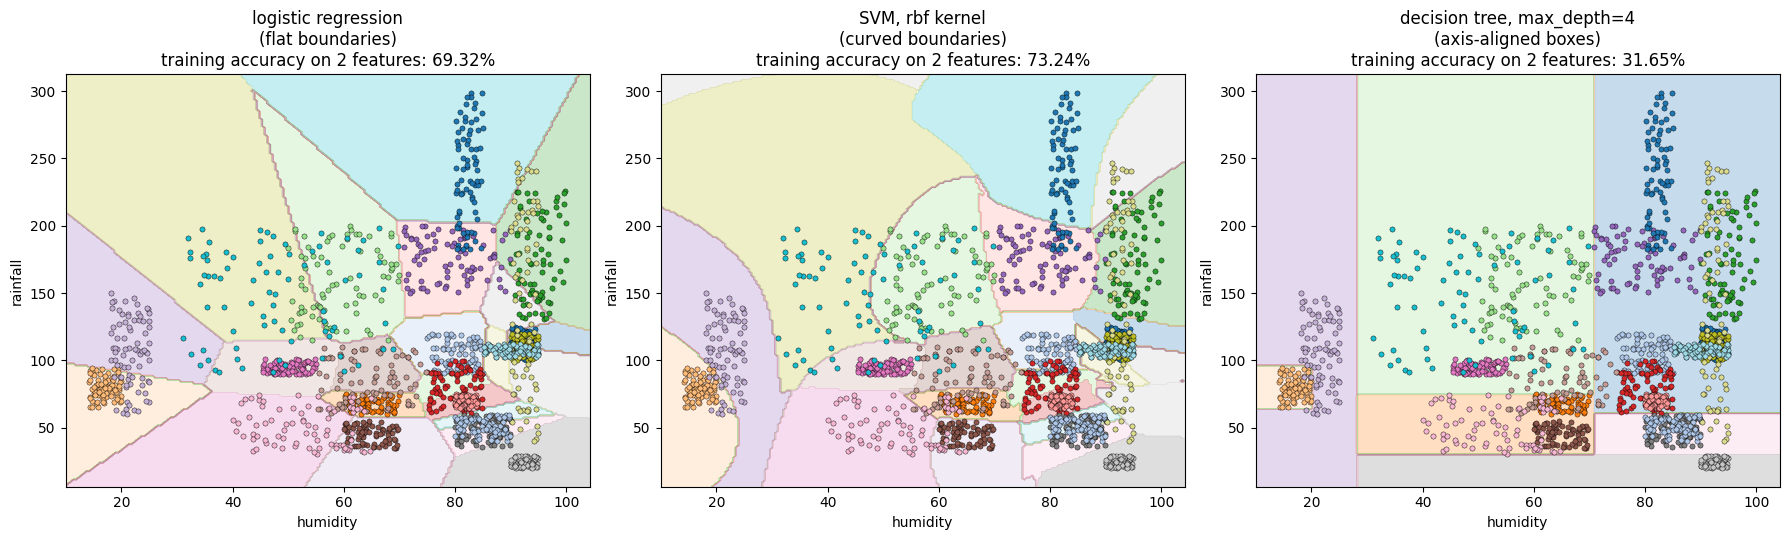

In [20]:
BOUNDARY_FEATURES = ["humidity", "rainfall"]
X_2d = X_train[BOUNDARY_FEATURES]


def make_pipeline_2d(model) -> Pipeline:
    """As `make_pipeline`, but scaling only the two features being plotted."""
    return Pipeline(
        [("preprocess", build_preprocessor(BOUNDARY_FEATURES)), ("model", model)]
    )


illustrations = {
    "logistic regression\n(flat boundaries)": get_logistic_regression(),
    "SVM, rbf kernel\n(curved boundaries)": get_svm(),
    "decision tree, max_depth=4\n(axis-aligned boxes)": get_decision_tree(max_depth=4),
}

figure, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for panel, (name, model) in zip(axes, illustrations.items(), strict=True):
    fitted_2d = make_pipeline_2d(model).fit(X_2d, y_train)
    accuracy = evaluate_model(fitted_2d, X_2d, y_train)["accuracy"]
    plot_decision_boundary(
        fitted_2d,
        X_2d,
        y_train,
        ax=panel,
        title=f"{name}\ntraining accuracy on 2 features: {accuracy:.2%}",
    )
figure.tight_layout()

Three shapes, three algorithms, one dataset:

* **Logistic regression** cuts the plane with straight lines only. Every region
  is a polygon, because every boundary is `w . x + b = 0`.
* **The RBF SVM** encloses regions with curves. The kernel is what buys that, and
  the curvature is set by `gamma`.
* **The decision tree** produces rectangles with horizontal and vertical edges
  only, because every question it can ask is about *one* feature at a time. A
  diagonal boundary can only be approximated by a staircase — which is exactly
  what a deep tree spends its depth doing, and one reason trees overfit.

The scattered points that fall in the "wrong" colour are the crops that these two
features cannot separate; the full seven-feature models in the table below
separate almost all of them.

## 13. The extended results table

Same rows, same five folds, same seed, same metric, same preprocessor — the two
new models are simply appended to the Part 1 candidates. That is what makes this
a running record rather than two unrelated experiments.

In [21]:
candidates_v2 = {
    **candidates,
    "svm (rbf, C=1)": get_svm(),
    "decision tree (unlimited)": get_decision_tree(),
}

rows_v2 = []
for name, model in candidates_v2.items():
    outcome = cross_validated_accuracy(make_pipeline(model), X_train, y_train)
    rows_v2.append(
        {
            "model": name,
            **{f"fold {i}": round(score, 4) for i, score in enumerate(outcome["scores"], start=1)},
            "mean": round(outcome["mean"], 4),
            "std": round(outcome["std"], 4),
        }
    )

results_v2 = pd.DataFrame(rows_v2).set_index("model")
results_v2

/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,fold 1,fold 2,fold 3,fold 4,fold 5,mean,std
model,,,,,,,
baseline (most_frequent),0.0455,0.0455,0.0455,0.0455,0.0455,0.0455,0.0000
logistic regression,0.9659,0.9574,0.9688,0.9716,0.9773,0.9682,0.0066
knn (k=5),0.9830,0.9716,0.9460,0.9631,0.9631,0.9653,0.0121
naive bayes,1.0000,0.9972,0.9886,0.9915,0.9972,0.9949,0.0042
"svm (rbf, C=1)",0.9915,0.9830,0.9631,0.9716,0.9858,0.9790,0.0103
decision tree (unlimited),0.9943,0.9773,0.9886,0.9886,0.9773,0.9852,0.0068


In [22]:
summary_v2 = results_v2[["mean", "std"]].copy()
summary_v2["vs baseline"] = (summary_v2["mean"] - baseline_accuracy).round(4)
summary_v2["error rate"] = (1 - summary_v2["mean"]).round(4)
summary_v2 = summary_v2.sort_values("mean", ascending=False)

print(summary_v2.to_string())
print("\nbest so far:", summary_v2.drop(index="baseline (most_frequent)")["mean"].idxmax())

                             mean     std  vs baseline  error rate
model                                                             
naive bayes                0.9949  0.0042       0.9494      0.0051
decision tree (unlimited)  0.9852  0.0068       0.9397      0.0148
svm (rbf, C=1)             0.9790  0.0103       0.9335      0.0210
logistic regression        0.9682  0.0066       0.9227      0.0318
knn (k=5)                  0.9653  0.0121       0.9198      0.0347
baseline (most_frequent)   0.0455  0.0000       0.0000      0.9545

best so far: naive bayes


### Reading the extended table

* **Both new models beat the two Week 5 runners-up.** The tree reaches 98.52% and
  the SVM 97.90%, against logistic regression's 96.82% and KNN's 96.53%.
* **Naive Bayes still leads, at 99.49%.** Two more sophisticated algorithms did
  not displace the simplest one. Week 5's explanation still holds: the crops sit
  in compact, well-separated, roughly bell-shaped blobs, and "one Gaussian per
  crop per feature" describes exactly that shape.
* **The tree's 98.52% comes from a model that scores 100% on its training data.**
  Both facts are true at once, and only the second one is a result. This is the
  concrete reason to distrust training scores.
* **Error rates make the ranking legible.** Naive Bayes 0.5%, tree 1.5%, SVM
  2.1%, logistic regression 3.2%, KNN 3.5% — a three-fold spread that the
  accuracy column compresses into three percentage points.
* **Some of these gaps are still inside the noise.** The SVM and the tree are
  0.6 points apart with fold standard deviations of about 0.7 and 0.9; that is
  not a decided contest.

## 14. The result, and what it licenses

> ### Week 6 result — 5-fold stratified CV on the 1,760 training rows
>
> | Model | CV accuracy | vs. 4.55% baseline | Added |
> | --- | --- | --- | --- |
> | Gaussian naive Bayes | **99.49%** (±0.42) | +94.9 points | Week 5 |
> | Decision tree (unlimited) | 98.52% (±0.68) | +94.0 points | Week 6 |
> | SVM (rbf, `C = 1`) | 97.90% (±1.03) | +93.4 points | Week 6 |
> | Logistic regression | 96.82% (±0.66) | +92.3 points | Week 5 |
> | KNN, `k = 5` | 96.53% (±1.21) | +92.0 points | Week 5 |
> | `most_frequent` baseline | 4.55% (±0.00) | — | Week 4 |

The best-performing model so far is still **Gaussian naive Bayes at 99.49%**.

The cell below asserts the claims made above, so prose and numbers cannot drift
apart silently.

In [23]:
best_model_v2 = summary_v2.drop(index="baseline (most_frequent)")["mean"].idxmax()
best_accuracy_v2 = summary_v2.loc[best_model_v2, "mean"]
tree_train_accuracy = evaluate_model(
    make_pipeline(get_decision_tree()).fit(X_train, y_train), X_train, y_train
)["accuracy"]

print(f"BEST SO FAR   : {best_model_v2} at {best_accuracy_v2:.4f} ({best_accuracy_v2:.2%})")
print(f"NEW THIS WEEK : svm {summary_v2.loc['svm (rbf, C=1)', 'mean']:.4f},"
      f" tree {summary_v2.loc['decision tree (unlimited)', 'mean']:.4f}")
print(f"BASELINE      : {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")
print(f"protocol      : {DEFAULT_CV_FOLDS}-fold stratified CV, seed {DEFAULT_RANDOM_STATE},"
      " on data/processed/train.csv")

# Guard rails: these must hold for the conclusions above to be true.
assert best_model_v2 == "naive bayes"                       # still the leader
assert summary_v2.loc["decision tree (unlimited)", "mean"] > summary_v2.loc["knn (k=5)", "mean"]
assert summary_v2.loc["svm (rbf, C=1)", "mean"] > summary_v2.loc["knn (k=5)", "mean"]
assert tree_train_accuracy == 1.0                           # the unlimited tree memorises
assert depth_sweep.loc[1, "gap"] < depth_sweep["gap"].max()  # the gap opens with depth
assert len(train) == 1_760                                  # the test set was never touched

BEST SO FAR   : naive bayes at 0.9949 (99.49%)
NEW THIS WEEK : svm 0.9790, tree 0.9852
BASELINE      : 0.0455 (4.55%)
protocol      : 5-fold stratified CV, seed 42, on data/processed/train.csv


## 15. What Part 2 produced, and what it deliberately did not

**Produced**

* `get_svm()` and `get_decision_tree()` in `src/models/classical_models.py`,
  returning unfitted estimators like every other factory, and registered in
  `CLASSICAL_MODEL_FACTORIES`.
* `plot_decision_boundary()` in `src/utils/visualization.py`.
* A six-row results table, extending Week 5's rather than replacing it.
* The train-versus-validation curve over `max_depth`: overfitting and
  underfitting as a picture drawn from this dataset, and the bias-variance
  tradeoff attached to a concrete dial.
* Three decision boundaries drawn on `humidity` and `rainfall`, showing that a
  linear model cuts straight, an RBF SVM cuts curves, and a tree cuts boxes.
* The answer to "which model is best so far": Gaussian naive Bayes, 99.49%.

**Not produced, on purpose**

* **No ensemble.** No random forest, no gradient boosting, no voting or stacking
  classifier. A random forest is a crowd of deep trees whose variance cancels
  out — the natural next step from §11, and deliberately not taken here.
* **No systematic hyperparameter search.** The `C` sweep in §9 and the depth
  sweep in §11 are demonstrations of curves. Nothing from either is adopted:
  `C = 1.0` and `max_depth=None` remain the defaults, because choosing them from
  these tables would be selecting a hyperparameter by eye from validation scores,
  without a protocol, a search space, or a nested split to keep the choice
  honest.
* **No claim from the two-feature plots.** They are illustrations; every quoted
  score comes from the seven-feature cross-validated table.
* **No statement about which features drive a prediction** — Week 7, which starts
  from the tree's readable rules.
* **No precision, recall, F1 or confusion matrix** — Week 8.
* **No test-set score.** `data/processed/test.csv` remains unopened.